In [1]:
!pip install transformers==4.46.3
!pip install tf-keras

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from transformers import (
    BertTokenizerFast, TFBertForSequenceClassification,
    create_optimizer
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus)
if not gpus:
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU, "
          "or this will be extremely slow / may run out of time on Colab free tier.")

# -----------------------------
# 2. Mixed Precision (major speedup + memory savings on T4/A100)
# -----------------------------
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype policy:", mixed_precision.global_policy())


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype policy: <Policy "mixed_float16">


In [3]:
df = pd.read_csv('imdb_reviews.csv')
print(f"Total reviews loaded: {len(df)}")

Total reviews loaded: 50000


In [4]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

t0 = time.time()
df["clean_review"] = df["review"].apply(clean_text)
print(f"Cleaning took {time.time() - t0:.2f}s")

Cleaning took 5.69s


In [5]:
train_df = df[df["split_origin"] == "train"].reset_index(drop=True)
test_df = df[df["split_origin"] == "test"].reset_index(drop=True)

print(f"Official train set: {len(train_df)}")
print(f"Official test set : {len(test_df)}")

Official train set: 25000
Official test set : 25000


In [6]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["clean_review"].values,
    train_df["sentiment"].values,
    test_size=0.1,          # 10% of the 25k train set held out for validation
    random_state=SEED,
    stratify=train_df["sentiment"].values
)

X_test_text = test_df["clean_review"].values
y_test = test_df["sentiment"].values

print(f"\nTrain: {len(X_train_text)} | Val: {len(X_val_text)} | Test: {len(X_test_text)}")


Train: 22500 | Val: 2500 | Test: 25000


In [7]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256  # covers ~95%+ of reviews; 512 doubles compute cost for marginal gain

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [8]:
def encode_texts(texts, labels, batch_size_tok=1000):
    """Tokenize in chunks to avoid memory spikes on the full dataset."""
    input_ids, attention_masks = [], []
    for i in range(0, len(texts), batch_size_tok):
        chunk = list(texts[i:i + batch_size_tok])
        enc = tokenizer(
            chunk, padding="max_length", truncation=True,
            max_length=MAX_LEN, return_tensors="np"
        )
        input_ids.append(enc["input_ids"])
        attention_masks.append(enc["attention_mask"])
    input_ids = np.vstack(input_ids)
    attention_masks = np.vstack(attention_masks)
    return input_ids, attention_masks, np.array(labels)

In [9]:
t0 = time.time()
train_ids, train_mask, y_train_arr = encode_texts(X_train_text, y_train)
val_ids, val_mask, y_val_arr = encode_texts(X_val_text, y_val)
test_ids, test_mask, y_test_arr = encode_texts(X_test_text, y_test)
tokenize_time = time.time() - t0
print(f"Tokenization time (full dataset): {tokenize_time:.2f}s ({tokenize_time/60:.2f} min)")

Tokenization time (full dataset): 46.87s (0.78 min)


In [10]:
def make_dataset(ids, mask, labels, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {"input_ids": ids, "attention_mask": mask}, labels
    ))
    if shuffle:
        ds = ds.shuffle(10000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [11]:
BATCH_SIZE = 32
EPOCHS = 3

train_dataset = make_dataset(train_ids, train_mask, y_train_arr, BATCH_SIZE, shuffle=True)
val_dataset = make_dataset(val_ids, val_mask, y_val_arr, BATCH_SIZE)
test_dataset = make_dataset(test_ids, test_mask, y_test_arr, BATCH_SIZE)

steps_per_epoch = len(X_train_text) // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS
print(f"Steps per epoch: {steps_per_epoch} | Total training steps: {total_steps}")

Steps per epoch: 703 | Total training steps: 2109


In [12]:
model = TFBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

optimizer, schedule = create_optimizer(
    init_lr=2e-5,
    num_warmup_steps=int(0.1 * total_steps),
    num_train_steps=total_steps,
    weight_decay_rate=0.01
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=1, restore_best_weights=True
)

In [14]:
print(f"\nStarting fine-tuning on {len(X_train_text)} training examples "
      f"({EPOCHS} epochs, batch size {BATCH_SIZE})...")

t0 = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop],  # add checkpoint_cb here if using Drive
    verbose=1
)
bert_train_time = time.time() - t0
print(f"\nBERT fine-tuning time: {bert_train_time:.2f}s ({bert_train_time/60:.2f} min)")
print(f"Average time per epoch: {bert_train_time/len(history.history['loss']):.2f}s")


Starting fine-tuning on 22500 training examples (3 epochs, batch size 32)...
Epoch 1/3
704/704 [==============================] - 551s 743ms/step - loss: 0.3038 - accuracy: 0.8665 - val_loss: 0.2145 - val_accuracy: 0.9204
Epoch 2/3
704/704 [==============================] - 520s 738ms/step - loss: 0.1471 - accuracy: 0.9453 - val_loss: 0.2286 - val_accuracy: 0.9192

BERT fine-tuning time: 1070.75s (17.85 min)
Average time per epoch: 535.38s


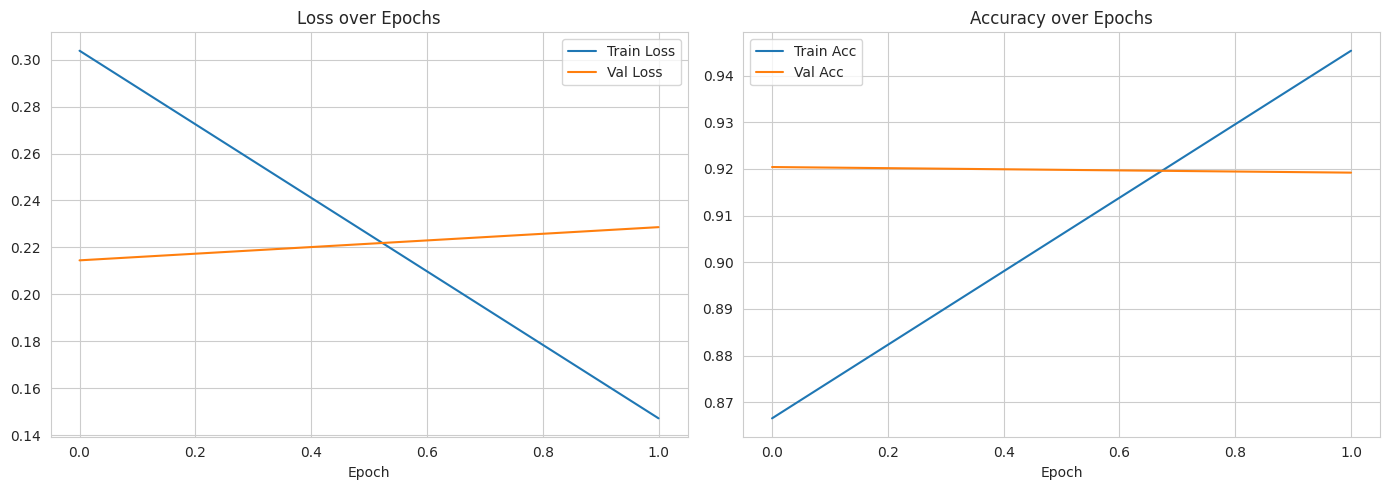

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

In [16]:
t0 = time.time()
logits = model.predict(test_dataset).logits
inference_time = time.time() - t0

y_proba = tf.nn.softmax(logits, axis=1).numpy()[:, 1]
y_pred = np.argmax(logits, axis=1)

acc = accuracy_score(y_test_arr, y_pred)
f1 = f1_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec = recall_score(y_test_arr, y_pred)
roc_auc = roc_auc_score(y_test_arr, y_proba)

print("\n===== BERT Evaluation (Official 25k Test Set) =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Inference time on {len(y_test_arr)} test samples: {inference_time:.2f}s")
print("\nClassification Report:\n", classification_report(y_test_arr, y_pred, target_names=["Negative", "Positive"]))


782/782 [==============================] - 205s 253ms/step

===== BERT Evaluation (Official 25k Test Set) =====
Accuracy : 0.9226
Precision: 0.9200
Recall   : 0.9256
F1-score : 0.9228
ROC-AUC  : 0.9764
Inference time on 25000 test samples: 205.30s

Classification Report:
               precision    recall  f1-score   support

    Negative       0.93      0.92      0.92     12500
    Positive       0.92      0.93      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



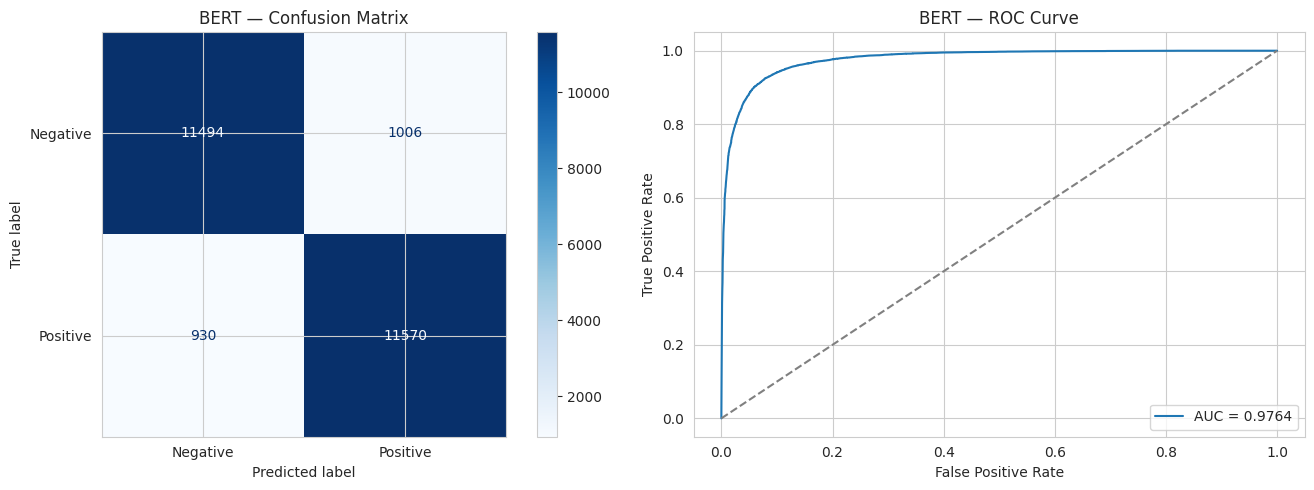

In [17]:
cm = confusion_matrix(y_test_arr, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("BERT — Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test_arr, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("BERT — ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

In [23]:
thresholds = np.arange(0.1, 0.91, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    threshold_results.append({
        "threshold": round(thresh, 2),
        "accuracy": accuracy_score(y_test_arr, y_pred_t),
        "precision": precision_score(y_test_arr, y_pred_t, zero_division=0),
        "recall": recall_score(y_test_arr, y_pred_t, zero_division=0),
        "f1": f1_score(y_test_arr, y_pred_t, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

 threshold  accuracy  precision  recall       f1
      0.10   0.86876   0.799377 0.98464 0.882389
      0.15   0.88776   0.829146 0.97680 0.896937
      0.20   0.90004   0.850937 0.97000 0.906576
      0.25   0.90780   0.867229 0.96304 0.912627
      0.30   0.91416   0.881335 0.95720 0.917702
      0.35   0.91760   0.892186 0.95000 0.920186
      0.40   0.92024   0.902714 0.94200 0.921939
      0.45   0.92152   0.911384 0.93384 0.922475
      0.50   0.92260   0.920080 0.92560 0.922832
      0.55   0.92200   0.927957 0.91504 0.921453
      0.60   0.92132   0.935068 0.90552 0.920057
      0.65   0.91928   0.942055 0.89352 0.917146
      0.70   0.91516   0.947641 0.87888 0.911966
      0.75   0.91012   0.954437 0.86136 0.905513
      0.80   0.90176   0.960227 0.83824 0.895097
      0.85   0.89080   0.967375 0.80888 0.881056
      0.90   0.87372   0.975374 0.76680 0.858602


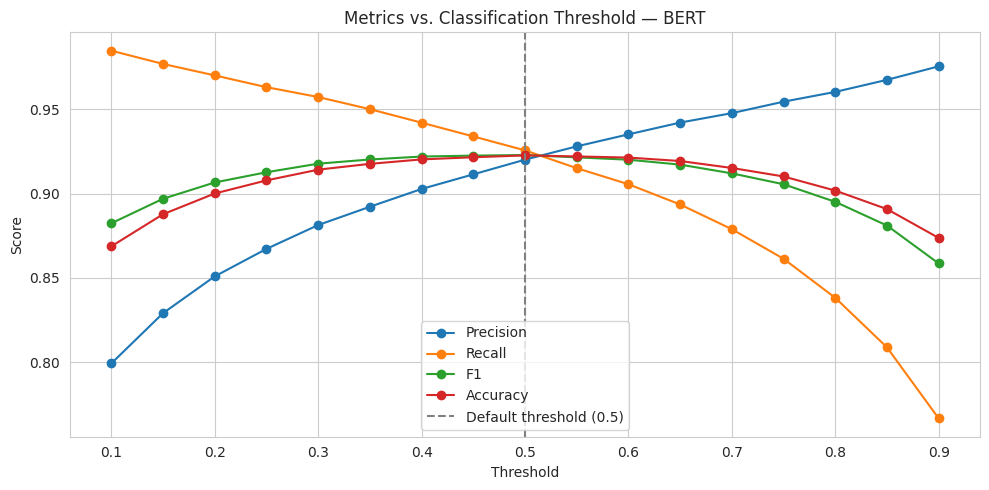


Best threshold by F1: 0.5 -> F1=0.9228


In [24]:
plt.figure(figsize=(10, 5))
plt.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", marker="o")
plt.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", marker="o")
plt.plot(thresh_df["threshold"], thresh_df["f1"], label="F1", marker="o")
plt.plot(thresh_df["threshold"], thresh_df["accuracy"], label="Accuracy", marker="o")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.title("Metrics vs. Classification Threshold — BERT")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# Best threshold by F1
best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"\nBest threshold by F1: {best_row['threshold']} -> F1={best_row['f1']:.4f}")

In [18]:
test_results_df = pd.DataFrame({
    "review": X_test_text,
    "true_label": y_test_arr,
    "pred_label": y_pred,
    "pred_proba": y_proba
})
misclassified = test_results_df[test_results_df.true_label != test_results_df.pred_label]
print(f"\nMisclassified: {len(misclassified)} / {len(test_results_df)} "
      f"({len(misclassified)/len(test_results_df)*100:.2f}%)")
misclassified.sample(min(5, len(misclassified)), random_state=SEED)[
    ["review", "true_label", "pred_label", "pred_proba"]
]


Misclassified: 1936 / 25000 (7.74%)


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,review,true_label,pred_label,pred_proba
7903,I remember this film as the other person that ...,1,0,0.020889
12201,This is the kind of movie that you rent when y...,1,0,0.008659
12259,What is he supposed to be? He was a kid in the...,1,0,0.009560
23272,"""Two wildlife photographers are traveling thro...",0,1,0.920898
19832,"It's a kinder, gentler Cyborg movie with a lov...",0,1,0.820312


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


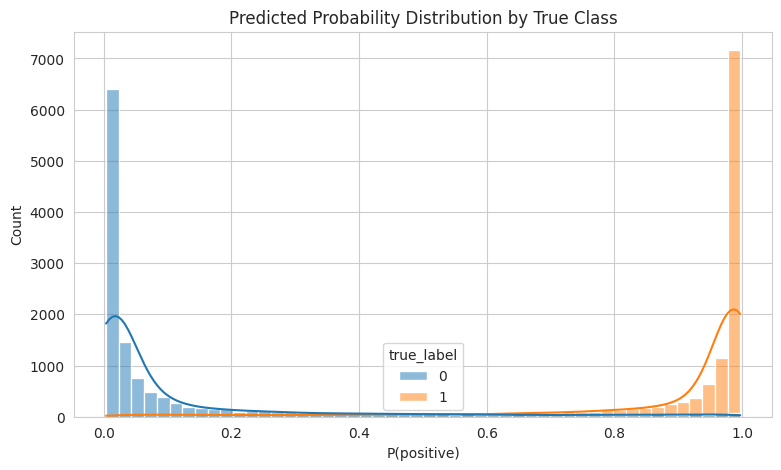

In [19]:
plt.figure()
sns.histplot(data=test_results_df, x="pred_proba", hue="true_label", bins=50, kde=True)
plt.title("Predicted Probability Distribution by True Class")
plt.xlabel("P(positive)")
plt.show()


In [21]:
model.save_pretrained("/content/drive/MyDrive/bert_imdb_finetuned")
tokenizer.save_pretrained("/content/drive/MyDrive/bert_imdb_finetuned")

('/content/drive/MyDrive/bert_imdb_finetuned/tokenizer_config.json',
 '/content/drive/MyDrive/bert_imdb_finetuned/special_tokens_map.json',
 '/content/drive/MyDrive/bert_imdb_finetuned/vocab.txt',
 '/content/drive/MyDrive/bert_imdb_finetuned/added_tokens.json',
 '/content/drive/MyDrive/bert_imdb_finetuned/tokenizer.json')

In [22]:
results_df = pd.DataFrame([{
    "model": "BERT (bert-base-uncased, official 25k/25k split)",
    "accuracy": acc, "precision": prec, "recall": rec,
    "f1": f1, "roc_auc": roc_auc
}])
print("\n================= FINAL RESULTS SUMMARY =================")
print(results_df.to_string(index=False))

print("\n================= TIMING SUMMARY =================")
print(f"Tokenization time      : {tokenize_time:.2f}s ({tokenize_time/60:.2f} min)")
print(f"Fine-tuning time       : {bert_train_time:.2f}s ({bert_train_time/60:.2f} min)")
print(f"Epochs run             : {len(history.history['loss'])}")
print(f"Avg time/epoch         : {bert_train_time/len(history.history['loss']):.2f}s")
print(f"Inference time (test)  : {inference_time:.2f}s")
print(f"Training set size      : {len(X_train_text)} (official Stanford split)")
print(f"Test set size          : {len(X_test_text)} (official Stanford split)")
print(f"TOTAL pipeline time    : {tokenize_time + bert_train_time:.2f}s "
      f"({(tokenize_time + bert_train_time)/60:.2f} min)")

results_df.to_csv("bert_results.csv", index=False)


================= FINAL RESULTS SUMMARY =================
                                           model  accuracy  precision  recall       f1  roc_auc
BERT (bert-base-uncased, official 25k/25k split)   0.92256   0.920006  0.9256 0.922795 0.976448

================= TIMING SUMMARY =================
Tokenization time      : 46.87s (0.78 min)
Fine-tuning time       : 1070.75s (17.85 min)
Epochs run             : 2
Avg time/epoch         : 535.38s
Inference time (test)  : 205.30s
Training set size      : 22500 (official Stanford split)
Test set size          : 25000 (official Stanford split)
TOTAL pipeline time    : 1117.62s (18.63 min)
